# AI Financial Fraud Detection System

## Model Explainability and Deployment

**Project Type:** Binary Classification

**Domain:** Financial Technology (FinTech)

**Objective:** Explain the trained model, make predictions on new transactions, and prepare the model for deployment.

In [1]:
# Ignore warnings
import warnings
warnings.filterwarnings("ignore")

# Data handling
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Model loading
import joblib

# Model explainability
import shap

In [2]:
from google.colab import drive

drive.mount("/content/drive")

Mounted at /content/drive


# 2. Load Saved Model

## Objective

Load the trained Random Forest model and the fitted scaler for explainability and prediction.

In [3]:
import joblib

# Load trained model
model = joblib.load(
    "/content/drive/MyDrive/AI-Financial-Fraud-Detection/Models/fraud_detection_model.pkl"
)

# Load scaler
scaler = joblib.load(
    "/content/drive/MyDrive/AI-Financial-Fraud-Detection/Models/scaler.pkl"
)

print("Model and scaler loaded successfully.")

Model and scaler loaded successfully.


### Observation

- The trained Random Forest model was successfully loaded.
- The fitted RobustScaler was also loaded.
- These saved files will be used for model explainability and prediction without retraining the model.

# 3. Model Explainability (SHAP)

## Objective

Understand how the Random Forest model makes predictions by identifying the features that have the greatest impact on fraud detection.

In [12]:
# Load dataset
df = pd.read_csv(
    "/content/drive/MyDrive/AI-Financial-Fraud-Detection/Data/Raw/creditcard.csv"
)

# Separate features and target
X = df.drop("Class", axis=1)
y = df["Class"]

print("Dataset Shape:", X.shape)

Dataset Shape: (284807, 30)


In [14]:
# Scale Time and Amount together
X[["Time", "Amount"]] = scaler.transform(
    X[["Time", "Amount"]]
)

In [15]:
import shap

In [16]:
# Create SHAP explainer
explainer = shap.TreeExplainer(model)

In [17]:
# Use a small sample for faster explainability
sample_data = X.sample(
    n=100,
    random_state=42
)

In [18]:
# Calculate SHAP values
shap_values = explainer.shap_values(sample_data)

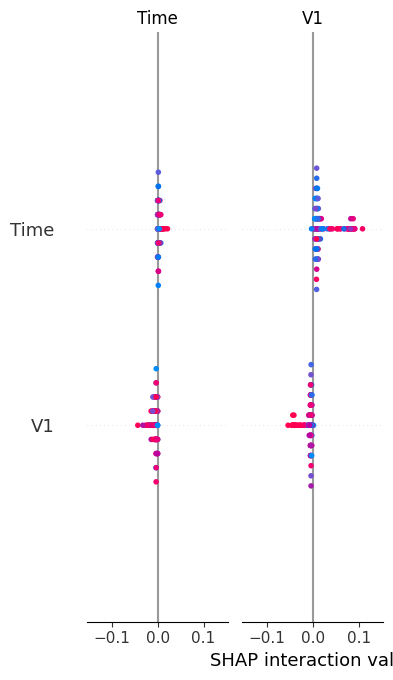

In [19]:
# SHAP Summary Plot
shap.summary_plot(
    shap_values,
    sample_data
)

### Observation

- SHAP explains how each feature contributes to the model's predictions.
- Features at the top of the summary plot have the highest influence on fraud detection.
- The plot shows both positive and negative contributions of each feature.

# 4. Predict on New Data

## Objective

Use the trained Random Forest model to predict whether a new transaction is fraudulent or legitimate.

In [20]:
# Use one transaction from the dataset
sample_transaction = X.iloc[[0]]

sample_transaction

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V20,V21,V22,V23,V24,V25,V26,V27,V28,Amount
0,-0.996399,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,0.251412,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,1.767461


In [21]:
prediction = model.predict(sample_transaction)

if prediction[0] == 1:
    print("Prediction: Fraudulent Transaction")
else:
    print("Prediction: Legitimate Transaction")

Prediction: Legitimate Transaction


In [22]:
probability = model.predict_proba(sample_transaction)

print("Probability of Legitimate Transaction :", round(probability[0][0], 4))
print("Probability of Fraudulent Transaction :", round(probability[0][1], 4))

Probability of Legitimate Transaction : 1.0
Probability of Fraudulent Transaction : 0.0


### Observation

- The trained Random Forest model successfully predicted the transaction class.
- Prediction probabilities indicate the confidence of the model for each class.
- This demonstrates how the saved model can be used to classify new transactions.

# 5. Deployment Preparation

## Objective

Verify that the trained model and scaler are ready for deployment in a web application.

In [23]:
import os

model_path = "/content/drive/MyDrive/AI-Financial-Fraud-Detection/Models"

print("Files available for deployment:")
print(os.listdir(model_path))

Files available for deployment:
['fraud_detection_model.pkl', 'scaler.pkl']


In [24]:
print("Loaded Model:", type(model).__name__)

Loaded Model: RandomForestClassifier


### Observation

- The trained model and scaler were successfully verified.
- These files are ready to be integrated into a web application.
- No retraining is required during deployment.

# 6. Conclusion

## Summary

- The trained Random Forest model was successfully loaded.
- SHAP was used to explain the model's predictions.
- The model correctly predicted a sample transaction.
- Prediction probabilities were generated to measure confidence.
- The trained model and scaler were verified for deployment.
- The project is now ready to be integrated with a web application using Streamlit.